## Financial Forecasting using neural networks 

In this notebook I will try to predict the price and the log-returns of the S&P 500 for last 4 years ( from 2022-01-01 to 2026-01-24).
The S&P500 was chosen as the primary benchmark because it serves as a comprehensive barometer for the U.S. economy, tracking the performance of 500 leading publicly traded companies.
Additionally, since financial sentiment on paltforms like Reddit tends to focus on broad market trends rather than niche equities, the index should be a good representative of the global market trend.

### Import libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis, skew
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from datasets import load_dataset
import yfinance as yf
import arch
from math import sqrt
from sklearn.metrics import mean_squared_error,mean_absolute_error
from arch.unitroot import VarianceRatio
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from keras.layers import LSTM,Conv1D,Conv2D,MaxPooling2D,MaxPooling1D,Flatten, Bidirectional
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
seed=42

In [ ]:
# Set global seeds to ensure reproducible results across runs
import os
import random
seed = 42

def set_reproducibility(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(seed)

####  Download the dataframe using yfinance library

In [2]:
ticker = "SPY"
start = "2022-01-01"
end   = "2026-01-24"

# Download dataframe
df = yf.download(
    ticker,
    start=start,
    end=end,
    auto_adjust=False,
    progress=False,
    multi_level_index=False
)

In [3]:
# Cleanded dataset
df = df.dropna().copy()
df.index.name = "date" 

data_SPY = df[["Open", "High", "Low", "Close", "Volume", "Adj Close"]]

data_SPY.head()

,Open,High,Low,Close,Volume,Adj Close
date,,,,,,
2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875122
2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785
2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049713
2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633514
2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883545


### Price evolution of S&P 500

Text(0, 0.5, 'Adj. Close')

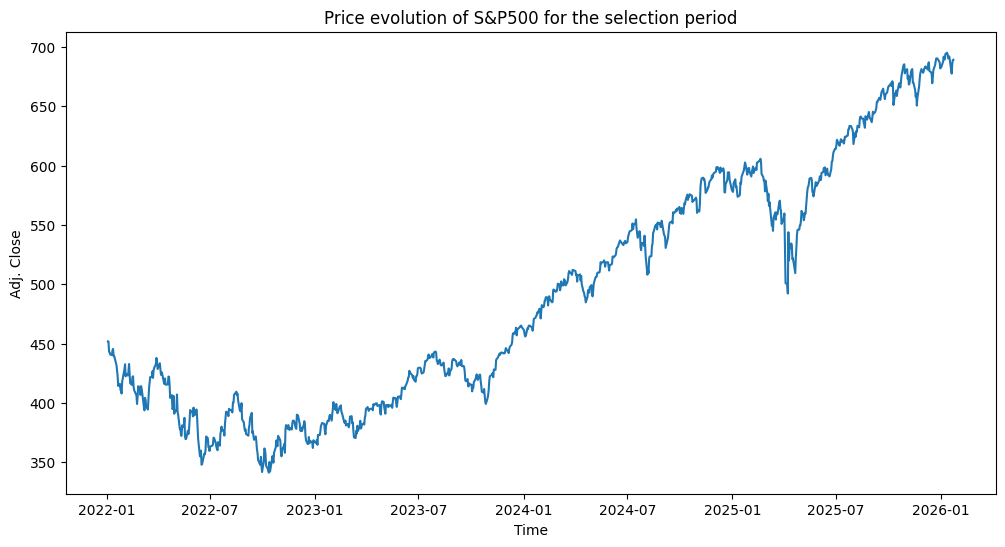

In [4]:
plt.figure(figsize=(12,6))
plt.plot(data_SPY.index, data_SPY['Adj Close'])
plt.title('Price evolution of S&P500 for the selection period')
plt.xlabel('Time')
plt.ylabel('Adj. Close')

### Log-Returns

In [5]:
log_returns = np.log(data_SPY / data_SPY.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
log_returns.head()

,Open,High,Low,Close,Volume,Adj Close
date,,,,,,
2022-01-04,0.006112,0.004448,0.003644,-0.000335,-0.020710,-0.000335
2022-01-05,-0.004308,-0.004176,-0.015469,-0.019389,0.384366,-0.019389
2022-01-06,-0.019619,-0.015093,-0.006105,-0.000940,-0.185274,-0.000940
2022-01-07,0.000128,-0.003447,-0.001677,-0.003961,-0.020322,-0.003961
2022-01-10,-0.011283,-0.007402,-0.017477,-0.001245,0.338198,-0.001245


Text(0.5, 1.0, 'Evolution of Log_returns')

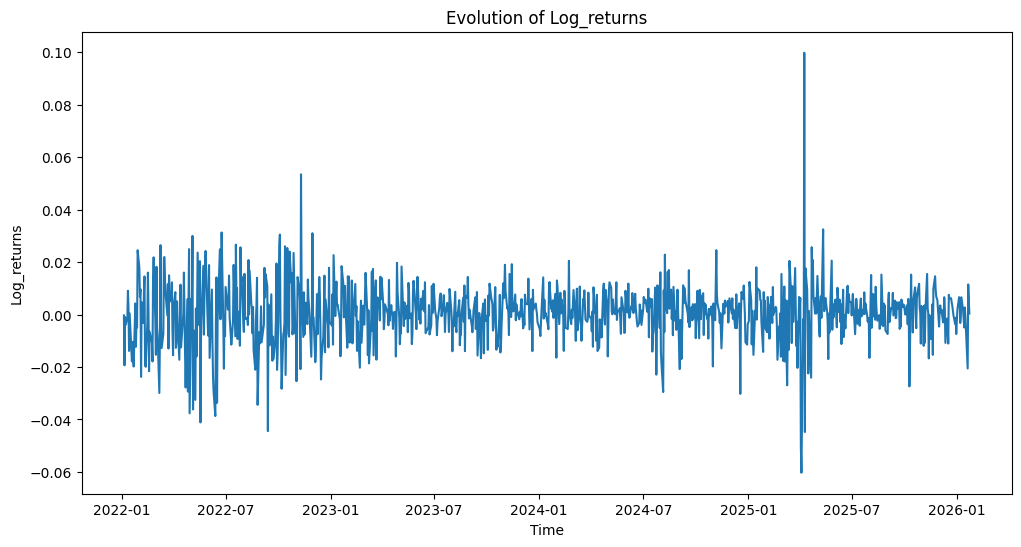

In [6]:
#Log-returns evolution plot
plt.figure(figsize=(12,6))
plt.plot(log_returns.index, log_returns['Close'])
plt.xlabel('Time')
plt.ylabel('Log_returns')
plt.title('Evolution of Log_returns')

Text(0.5, 1.0, 'Histogram of Log_returns')

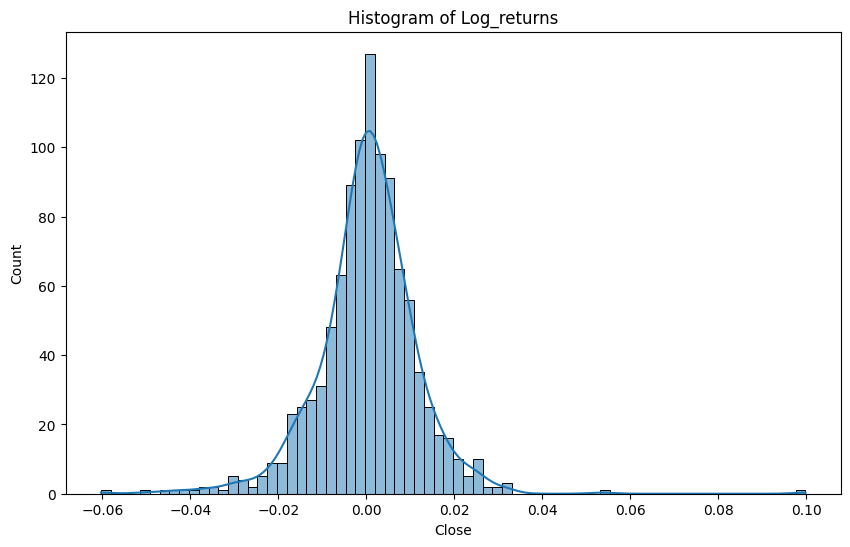

In [ ]:
#Histogram of Log_Returns
plt.figure(figsize=(10,6))
sns.histplot(data=log_returns, x='Close', kde=True)
plt.title('Histogram of Log_returns')

In [8]:
skewness = log_returns['Close'].skew()
kurt = log_returns['Close'].kurt()

skew_hurt = pd.DataFrame({
        'Metric': ['Skewness','Kurtosis'],
        'Value' : [skewness, kurt] 
})

skew_hurt


,Metric,Value
0,Skewness,0.185334
1,Kurtosis,8.077854


The log-returns show the presence of a positive shew of 0.18 indicating a distribution that leans slightly to the right.
The kurtosis of 8.07 confirms a highly leptokurtic distribution, signaling the presence of "fat tails", meaning that the market experiences extreme price swings far more often than a standard distribution.

### Efficient Market Hypothesis (EMH)

Text(0.5, 1.0, 'Autocorrelation of S&P 500 Log Returns')

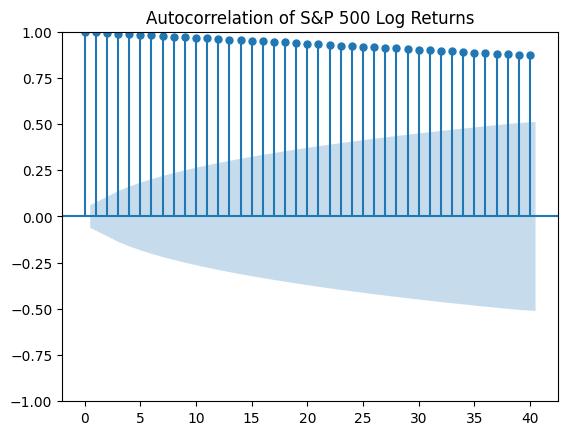

In [9]:
plot_acf(data_SPY['Close'], lags=40)
plt.title('Autocorrelation of S&P 500 Log Returns')

<Figure size 800x500 with 0 Axes>

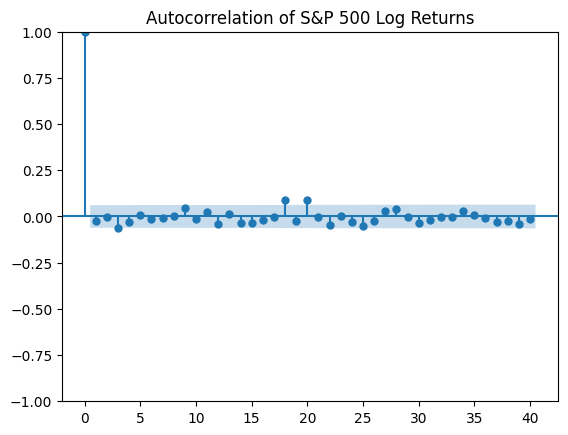

In [10]:
plt.figure(figsize=(8, 5))
plot_acf(log_returns['Close'], lags=40)
plt.title('Autocorrelation of S&P 500 Log Returns')
plt.show()

In [11]:
#L-jung Box test
#H0: The series of returns is white noise (randomly distributed).
#H1: The series of returns is not white noise (exhibits serial correlation).

res_returns = acorr_ljungbox(log_returns['Close'], lags=[10], return_df=True)
res_returns

,lb_stat,lb_pvalue
10,8.321316,0.597483


In [12]:
# Run test on squared returns (checks for volatility prediction)
res_volatility = acorr_ljungbox(log_returns['Close']**2, lags=[10], return_df=True)
res_volatility

,lb_stat,lb_pvalue
10,192.623092,5.560992e-36


This show that the series of volatitiliy is not white noise, showing the existance of "Volatility Clustering"

In [13]:
#Variance Ratio test
#H0: The series follows a random walk (The variance ratio is equal to 1).
#H1: The series does not follow a random walk (The variance ratio is significantly different from 1).
vr = VarianceRatio(log_returns['Close'], lags=10)

print(vr.summary())

     Variance-Ratio Test Results     
Test Statistic                 -4.465
P-value                         0.000
Lags                               10
-------------------------------------

Computed with overlapping blocks (de-biased)


The Random Walk Hypothesis is rejected (as the Variance Ratio is significantly different from 1), suggesting that over medium and long-term horizons, the series exhibits autocorrelation or other dynamics that cause it to deviate from a pure random walk. This indicates that price movements are systematically influenced by market volatility and external factors.
Because the market isn't perfectly efficient, it means there are patterns hidden in the noise. By moving beyond just looking at prices and including sentiment analysis (like financial news), we can try to capture the human irrationality that the EMH ignores.

### LSTM with sentiment analysis 

In [14]:
data_final_news = pd.read_csv('../datasets/Data_final_news_reddit.csv')
data_final_news.head()

,date,clean,transformer_sentiment_label,transformer_sentiment_score
0,2009-05-09,sp500 elliott wave update competiting interpre...,neutral,0
1,2009-06-04,the gold bull market and the fed it rode in on,neutral,0
2,2009-06-25,what inflation rates fall as fed sells 25b i...,negative,-1
3,2009-10-10,tmobile sidekick disaster microsoft and tmobil...,negative,-1
4,2010-05-10,correlation math signals bull market oil\r\nst...,positive,1


In [15]:
data_SPY_reset = data_SPY.reset_index()
data_SPY_reset.head()

,date,Open,High,Low,Close,Volume,Adj Close
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875122
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049713
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633514
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883545


In [16]:
data_SPY_reset['date'] = pd.to_datetime(data_SPY_reset['date'])
data_final_news['date'] = pd.to_datetime(data_final_news['date'])

In [18]:
final_dataset = pd.merge(data_SPY_reset,
                         data_final_news[['date', 'transformer_sentiment_score']],
                         on='date',
                         how='left')

In [19]:
final_dataset[['transformer_sentiment_score']] = final_dataset[['transformer_sentiment_score']].fillna(0)

In [20]:
final_dataset.head(10)

,date,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875122,-1.0
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785,0.0
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049713,0.0
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633514,0.0
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883545,0.0
5,2022-01-10,462.700012,465.739990,456.600006,465.510010,119362000,440.334869,0.0
6,2022-01-11,465.230011,469.850006,462.049988,469.750000,74303100,444.345703,0.0
7,2022-01-12,471.589996,473.200012,468.940002,471.019989,67605400,445.546936,1.0
8,2022-01-13,472.190002,472.880005,463.440002,464.529999,91173100,439.407928,0.0
9,2022-01-14,461.190002,465.089996,459.899994,464.720001,95890900,439.587677,0.0


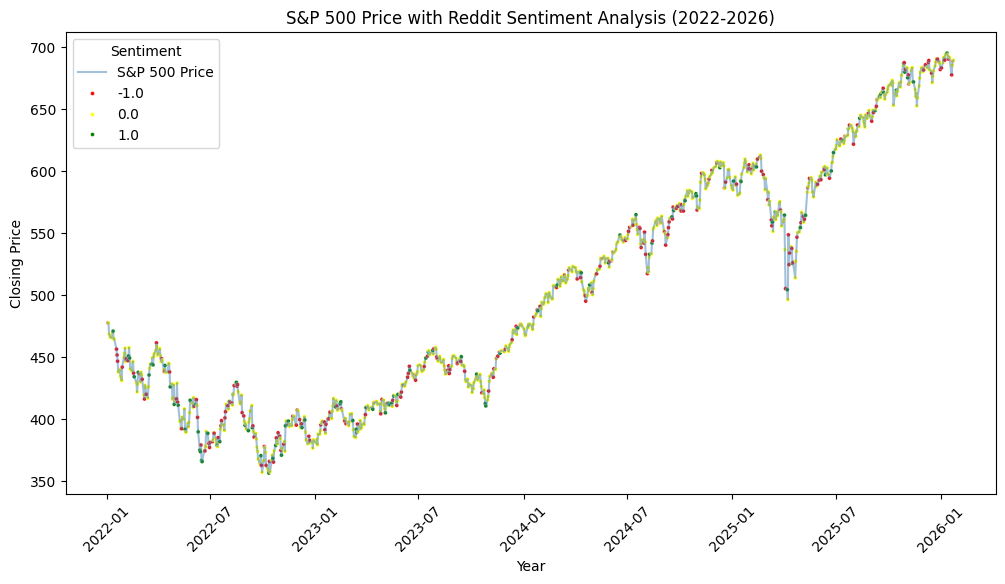

In [21]:
#Plot to showcase the sentiment scores in the price evolution of S&P500
palette_colors = {1.0: 'green', -1.0: 'red', 0.0: 'yellow'}

plt.figure(figsize=(12, 6))
sns.lineplot(data=final_dataset, x='date', y='Close', color='steelblue', alpha=0.5, label='S&P 500 Price')
sns.scatterplot(data=final_dataset, 
                x='date', 
                y='Close', 
                hue='transformer_sentiment_score', 
                palette=palette_colors,
                s=8)
plt.xticks(rotation=45)
plt.title('S&P 500 Price with Reddit Sentiment Analysis (2022-2026)')
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.legend(title='Sentiment', loc='upper left')

In [22]:
final_dataset['transformer_sentiment_score'].value_counts()

transformer_sentiment_score
 0.0    682
-1.0    227
 1.0    109
Name: count, dtype: int64

In [23]:
final_dataset.head()

,date,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875122,-1.0
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785,0.0
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049713,0.0
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633514,0.0
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883545,0.0


In [24]:
 # this create a more smooth score for the sentiment score
final_dataset['sentiment_score_smooth'] = final_dataset['transformer_sentiment_score'].rolling(window=3, min_periods=1).mean()
final_dataset['sentiment_score_smooth'] = final_dataset['sentiment_score_smooth'].ffill()
final_dataset.head(10)

,date,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score,sentiment_score_smooth
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875122,-1.0,-1.000000
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785,0.0,-0.500000
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049713,0.0,-0.333333
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633514,0.0,0.000000
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883545,0.0,0.000000
5,2022-01-10,462.700012,465.739990,456.600006,465.510010,119362000,440.334869,0.0,0.000000
6,2022-01-11,465.230011,469.850006,462.049988,469.750000,74303100,444.345703,0.0,0.000000
7,2022-01-12,471.589996,473.200012,468.940002,471.019989,67605400,445.546936,1.0,0.333333
8,2022-01-13,472.190002,472.880005,463.440002,464.529999,91173100,439.407928,0.0,0.333333
9,2022-01-14,461.190002,465.089996,459.899994,464.720001,95890900,439.587677,0.0,0.333333


### LSTM model

In [112]:
train_dates = pd.to_datetime(final_dataset['date'])

#Variables for training
cols = [
    'Open',
    'High', 'Low',
    'Close',
    'Volume',
    'Adj Close',
    'transformer_sentiment_score'
        ]

#New dataframe with only training data
df_for_training = final_dataset[cols].astype(float)
df_for_training.index=final_dataset['date']
df_for_training

,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score
date,,,,,,,
2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200.0,451.875122,-1.0
2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700.0,451.723785,0.0
2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900.0,443.049713,0.0
2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900.0,442.633514,0.0
2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600.0,440.883545,0.0
...,...,...,...,...,...,...,...
2026-01-16,693.659973,694.250000,690.099976,691.659973,79289200.0,691.659973,0.0
2026-01-20,681.489990,684.770020,676.570007,677.580017,111623300.0,677.580017,-1.0
2026-01-21,679.650024,688.739990,678.130005,685.400024,127844500.0,685.400024,0.0


### Standardize the data

In [121]:
scaler = StandardScaler()
scaler = scaler.fit(df_for_training)
df_for_training_scaled = scaler.transform(df_for_training)
scaler_for_inference = StandardScaler()
scaler_for_inference.fit_transform(df_for_training.loc[:,['Adj Close']])
df_for_training_scaled

array([[-0.27163428, -0.28603511, -0.2646953 , ..., -0.13648385,
        -0.38381467, -1.5711712 ],
       [-0.24089876, -0.26357176, -0.246485  , ..., -0.18703166,
        -0.38532343,  0.205998  ],
       [-0.26258192, -0.28466406, -0.32332686, ...,  0.94508313,
        -0.47180013,  0.205998  ],
       ...,
       [ 1.86879055,  1.93804281,  1.88561701, ...,  1.7359841 ,
         1.94432619,  0.205998  ],
       [ 1.97615334,  1.96324827,  1.97814294, ...,  0.01432814,
         1.98001678, -1.5711712 ],
       [ 1.95825997,  1.96145561,  1.98066915, ..., -0.46256217,
         1.98250917,  0.205998  ]], shape=(1018, 7))

In [122]:
#Empty lists to be populated using formatted training data
trainX = []
trainY = []

n_future = 1   # Number of days to look into the future based on the past days.
n_past = 5  # Number of past days too use to predict the future.

for i in range(n_past, len(df_for_training_scaled) - n_future +1):
    trainX.append(df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])
    trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future,[5]])

trainX, trainY = np.array(trainX), np.array(trainY)

print('TrainX shape = {}.'.format(trainX.shape))
print('TrainY shape = {}.'.format(trainY.shape))

TrainX shape = (1013, 5, 7).
TrainY shape = (1013, 1, 1).


In [123]:
#train test split

x_train_no_news, x_temp_no_news, y_train_no_news, y_temp_no_news = train_test_split(trainX[:,:,:-1], trainY, test_size=0.2, shuffle=False)

x_train_news, x_temp_news, y_train_news, y_temp_news = train_test_split(trainX, trainY, test_size=0.2, shuffle=False)


In [124]:
#creating the test and validation sets

x_val_no_news, x_test_no_news, y_val_no_news, y_test_no_news = train_test_split(x_temp_no_news, y_temp_no_news, test_size=0.5, shuffle=False)

x_val_news, x_test_news, y_val_news, y_test_news = train_test_split(x_temp_news, y_temp_news, test_size=0.5, shuffle=False)

print(f'Train size: {x_train_no_news.shape}, Validation size: {x_val_no_news.shape}, Test size:  {x_test_no_news.shape}')

Train size: (810, 5, 6), Validation size: (101, 5, 6), Test size:  (102, 5, 6)


In [99]:
#create the model
def build_model(input_shape):
    tf.random.set_seed(seed)
    cnn_lstm_model = Sequential()

    #cnn_lstm_model.add(Conv1D(filters=128, kernel_size=2, strides=1, padding='valid', input_shape=input_shape))
    #cnn_lstm_model.add(MaxPooling1D(pool_size=2, strides=2))

    #cnn_lstm_model.add(Conv1D(filters=64, kernel_size=2, strides=1, padding='valid'))
    #cnn_lstm_model.add(MaxPooling1D(pool_size=1, strides=2))

    cnn_lstm_model.add(Bidirectional(LSTM(256, return_sequences=True)))
    cnn_lstm_model.add(Dropout(0.2))
    cnn_lstm_model.add(Bidirectional(LSTM(256, return_sequences=True)))
    cnn_lstm_model.add(Dropout(0.2))

    cnn_lstm_model.add(Dense(32, activation='relu'))


    cnn_lstm_model.add(Dense(trainY.shape[2], activation='relu'))

    cnn_lstm_model.compile(optimizer='adam', loss='mse')
    cnn_lstm_model.summary()
    return cnn_lstm_model

In [129]:
#this is the new model
def build_model(input_shape):
    tf.random.set_seed(seed)
    model = Sequential()

    # First layer MUST return sequences so the second LSTM can see them
    model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.2))

    # LAST LSTM layer should return_sequences=False to get a single vector output
    model.add(Bidirectional(LSTM(256, return_sequences=False))) 
    model.add(Dropout(0.2))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(trainY.shape[2])) #,activation='relu'))

    model.compile(optimizer='adam', loss='mse')
    return model

In [130]:
# fit the model

lstm_model_no_news=build_model((x_train_no_news.shape[1],x_train_no_news.shape[2]))
lstm_model_news=build_model((x_train_news.shape[1],x_train_news.shape[2]))

history_without_news = lstm_model_no_news.fit(x_train_no_news, y_train_no_news, epochs=50, batch_size=32, validation_data=(x_val_no_news, y_val_no_news), verbose=1 )


history_news = lstm_model_news.fit(x_train_news, y_train_news, epochs=50, batch_size=32, validation_data=(x_val_news, y_val_news), verbose=1 )

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.1900 - val_loss: 0.0479
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0117 - val_loss: 0.0317
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0075 - val_loss: 0.0290
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0071 - val_loss: 0.0198
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0074 - val_loss: 0.0293
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0064 - val_loss: 0.0187
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0066 - val_loss: 0.0221
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0069 - val_loss: 0.0327
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0080 - val_loss: 0.0341
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0074 - val_loss: 0.0275
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0073 - val_loss: 0.0253
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.

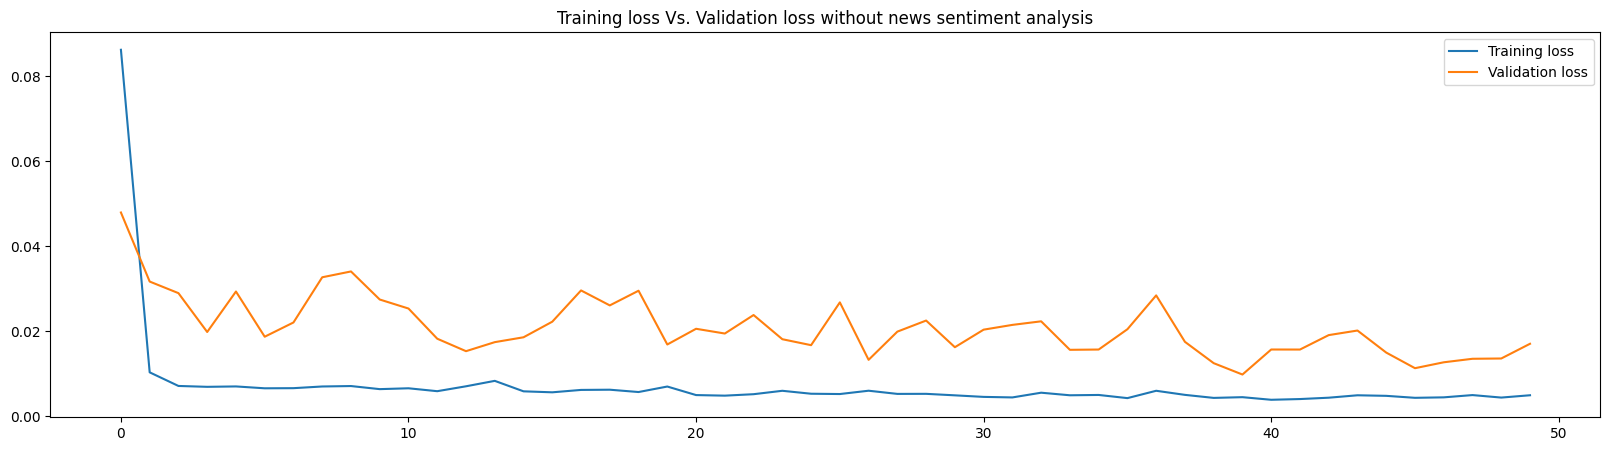

In [131]:
plt.figure(figsize=(20,5))
plt.plot(history_without_news.history['loss'], label='Training loss')
plt.plot(history_without_news.history['val_loss'], label='Validation loss')
plt.title('Training loss Vs. Validation loss without news sentiment analysis')
plt.legend()

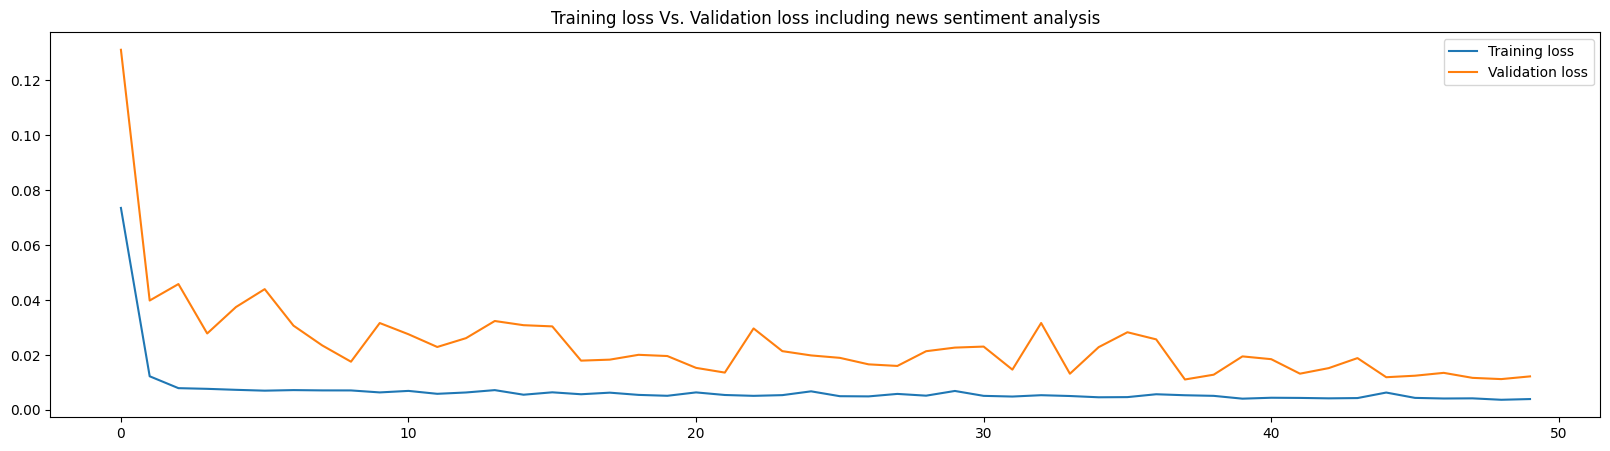

In [132]:
plt.figure(figsize=(20,5))
plt.plot(history_news.history['loss'], label='Training loss')
plt.plot(history_news.history['val_loss'], label='Validation loss')
plt.title('Training loss Vs. Validation loss including news sentiment analysis')
plt.legend()

In [133]:

def plot_predictions_with_dates(type_data, news, dates, y_actual, y_pred):
    plt.figure(figsize=(15, 6))
    
    # Titlu dinamic în funcție de prezența știrilor
    title_suffix = "With News Sentiment Analysis" if news else "Without News Sentiment Analysis"
    plt.title(f'LSTM {type_data} Prediction of Adj Close - {title_suffix}')
    
    # Plotting cu Seaborn
    sns.lineplot(x=dates, y=y_actual.flatten(), label='Actual Price', color='royalblue')
    sns.lineplot(x=dates, y=y_pred.flatten(), label='Predicted Price', color='orange')
    
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.show()
    
    # Calculăm metricile (pe valorile reale, nu scalate)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    
    print(f"Performance Metrics ({title_suffix})")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")

In [134]:
#Make prediction
training_prediction_without_news = lstm_model_no_news.predict(x_train_no_news)

training_prediction_news = lstm_model_news.predict(x_train_news)

training_prediction_without_news=training_prediction_without_news.reshape(training_prediction_without_news.shape[0], training_prediction_without_news.shape[2])

training_prediction_news=training_prediction_news.reshape(training_prediction_news.shape[0], training_prediction_news.shape[2])

y_train_pred_lstm_without_news = scaler_for_inference.inverse_transform(training_prediction_without_news)

y_train_pred_lstm_news = scaler_for_inference.inverse_transform(training_prediction_news)

y_train_lstm_reshaped_without_news=y_train_no_news.reshape(y_train_no_news.shape[0], y_train_news.shape[2])

y_train_actual_lstm = scaler_for_inference.inverse_transform(y_train_lstm_reshaped_without_news)
training_dates = df_for_training.index[n_past : n_past + len(y_train_actual_lstm)]

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


IndexError: tuple index out of range

In [135]:
# 1. Get Predictions
pred_no_news = lstm_model_no_news.predict(x_train_no_news)
pred_news = lstm_model_news.predict(x_train_news)

# 2. Reshape to 2D (Samples, Features) 
# Note: If your model outputs (809, 5, 1), use pred_no_news[:, -1, :] instead of reshape
pred_no_news = pred_no_news.reshape(pred_no_news.shape[0], -1)
pred_news = pred_news.reshape(pred_news.shape[0], -1)

# 3. Inverse Transform Predictions
y_train_pred_no_news = scaler_for_inference.inverse_transform(pred_no_news)
y_train_pred_news = scaler_for_inference.inverse_transform(pred_news)

# 4. Process Actual Values (y_train)
y_actual_2d = y_train_no_news.reshape(y_train_no_news.shape[0], -1)
y_train_actual_lstm = scaler_for_inference.inverse_transform(y_actual_2d)

# 5. Align Dates
training_dates = df_for_training.index[n_past : n_past + len(y_train_actual_lstm)]

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


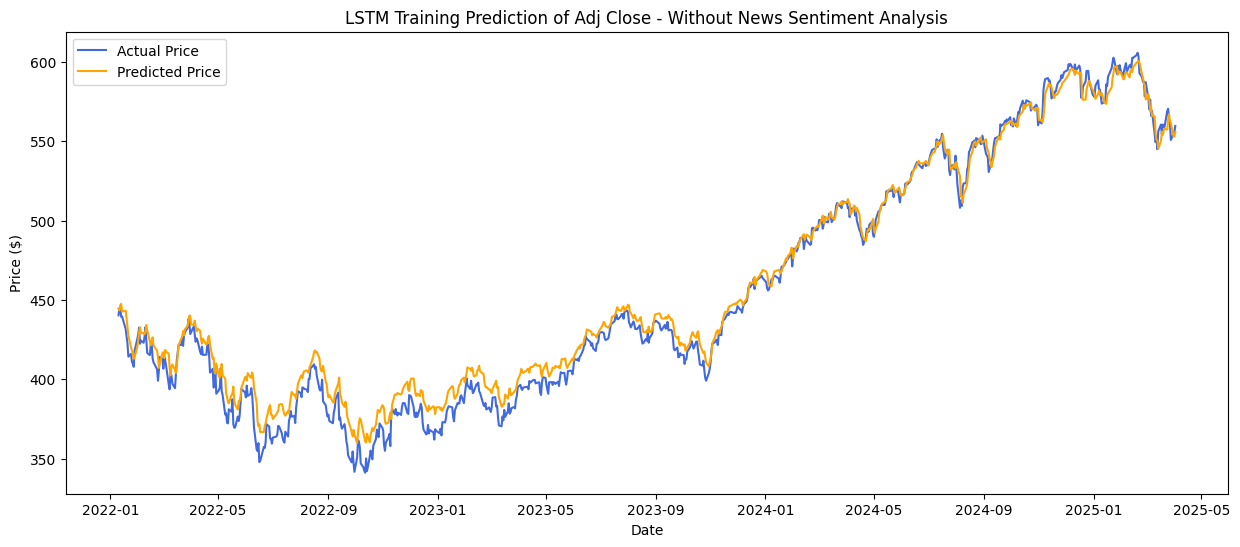

Performance Metrics (Without News Sentiment Analysis)
Mean Squared Error (MSE): 82.6486
Root Mean Squared Error (RMSE): 9.0911
Mean Absolute Error (MAE): 7.1917


In [136]:
plot_predictions_with_dates('Training',False,training_dates,y_train_actual_lstm,y_train_pred_no_news)

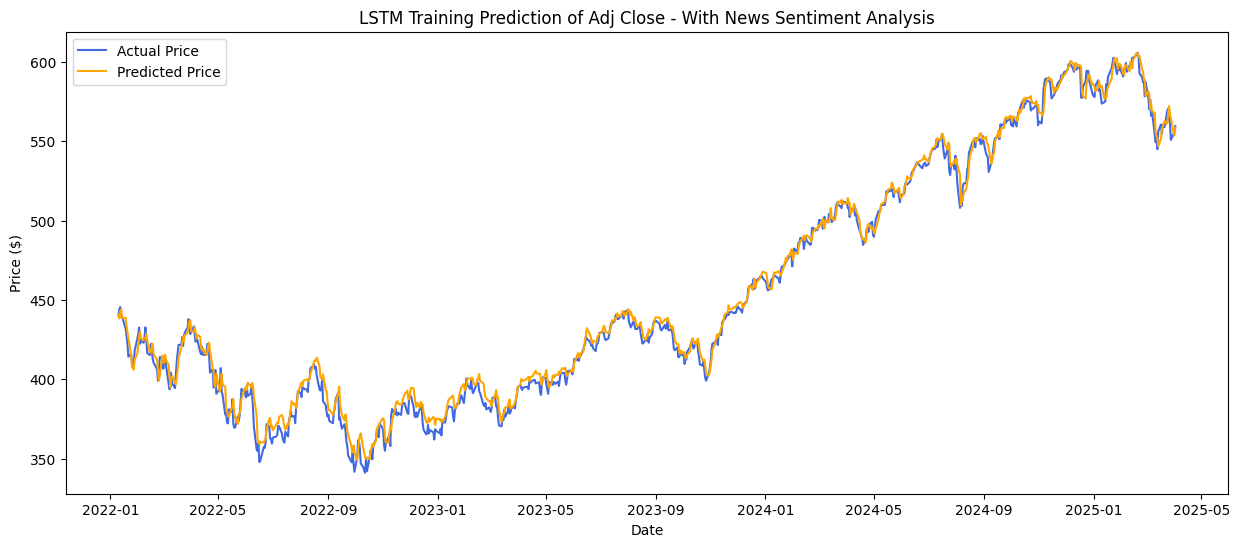

Performance Metrics (With News Sentiment Analysis)
Mean Squared Error (MSE): 34.2685
Root Mean Squared Error (RMSE): 5.8539
Mean Absolute Error (MAE): 4.4976


In [137]:
plot_predictions_with_dates('Training',True,training_dates,y_train_actual_lstm,y_train_pred_news)

In [138]:
# 1. Get Predictions
pred_no_news = lstm_model_no_news.predict(x_train_no_news)
pred_news = lstm_model_news.predict(x_train_news)

# 2. Reshape to 2D (Samples, Features) 
# Note: If your model outputs (809, 5, 1), use pred_no_news[:, -1, :] instead of reshape
pred_no_news = pred_no_news.reshape(pred_no_news.shape[0], -1)
pred_news = pred_news.reshape(pred_news.shape[0], -1)

# 3. Inverse Transform Predictions
y_train_pred_no_news = scaler_for_inference.inverse_transform(pred_no_news)
y_train_pred_news = scaler_for_inference.inverse_transform(pred_news)

# 4. Process Actual Values (y_train)
y_actual_2d = y_train_no_news.reshape(y_train_no_news.shape[0], -1)
y_train_actual_lstm = scaler_for_inference.inverse_transform(y_actual_2d)

# 5. Align Dates
training_dates = df_for_training.index[n_past : n_past + len(y_train_actual_lstm)]

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [139]:
testing_dates= df_for_training.index[-x_test_no_news.shape[0]:]
#Make prediction
testing_no_news = lstm_model_no_news.predict(x_test_no_news)
testing_news = lstm_model_news.predict(x_test_news)

testing_no_news=testing_no_news.reshape(testing_no_news.shape[0], -1)
testing_news=testing_news.reshape(testing_news.shape[0], -1)

y_test_pred_no_news = scaler_for_inference.inverse_transform(testing_no_news)
y_test_pred_news = scaler_for_inference.inverse_transform(testing_news)

# 4. Process Actual Values (y_train)
y_actual_2d = y_test_no_news.reshape(y_test_no_news.shape[0], -1)
y_test_actual_lstm = scaler_for_inference.inverse_transform(y_actual_2d)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


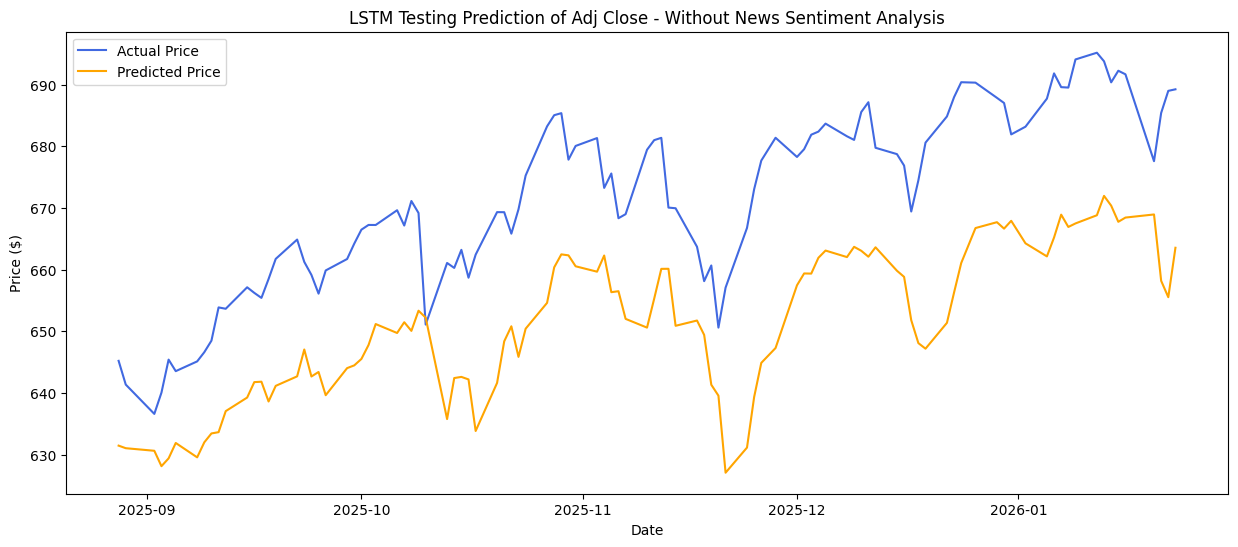

Performance Metrics (Without News Sentiment Analysis)
Mean Squared Error (MSE): 454.8854
Root Mean Squared Error (RMSE): 21.3280
Mean Absolute Error (MAE): 20.2914


In [140]:
plot_predictions_with_dates('Testing',False,testing_dates,y_test_actual_lstm,y_test_pred_no_news)

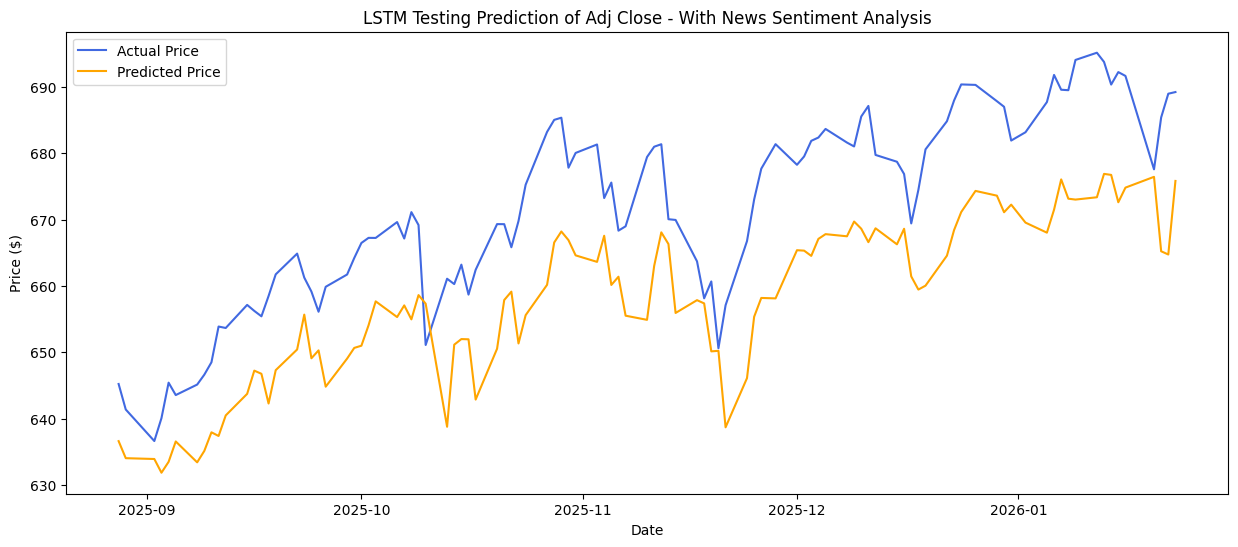

Performance Metrics (With News Sentiment Analysis)
Mean Squared Error (MSE): 218.3066
Root Mean Squared Error (RMSE): 14.7752
Mean Absolute Error (MAE): 13.7604


In [141]:
plot_predictions_with_dates('Testing',True,testing_dates,y_test_actual_lstm,y_test_pred_news)